In [11]:
!pip install shap
import shap

In [23]:

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np



In [2]:
df = pd.read_csv("/content/ecommerce_customer_churn_cleaned.csv")

In [3]:

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
numeric_features = X.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['boolean','uint8','object']).columns.tolist()


In [5]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [6]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        random_state=42
    ))
])

In [7]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount',
                                                   'CashbackAmount_log',
                                                   'DaySinceLastOrder_log',
                                                   'NumberOfDeviceRegistered_log',
                                                   'DevicesPerAddress',
                                                   'CashbackPerTenure']),
                                                 ('cat', 'passthrough',
                                                  ['PreferedOrderCat_Grocery',
                                                   'PreferedOrderCat_Laptop & '
                                                   'Accessory',
                                                   'PreferedOrderCat_Mobile',
                                                   'PreferedOrderCat_Others',
                                                   'MaritalStatus_Married',
                                                   'MaritalStatus_Single'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(max_depth=12, n_estimators=500,
                                        random_state=42))])

In [8]:

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.95      0.96       654
           1       0.79      0.81      0.80       135

    accuracy                           0.93       789
   macro avg       0.87      0.88      0.88       789
weighted avg       0.93      0.93      0.93       789



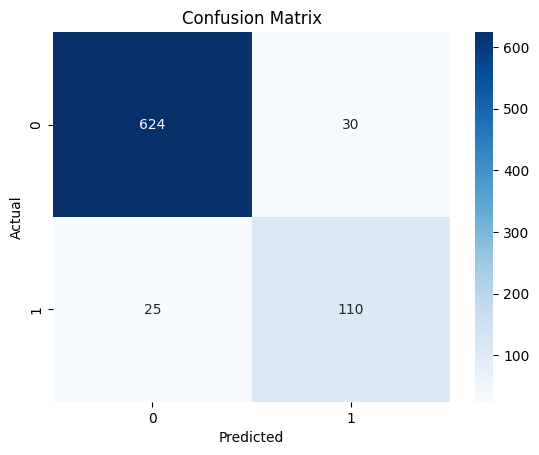

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('confusion Matrix.png')
plt.show()


ROC-AUC Score: 0.9520


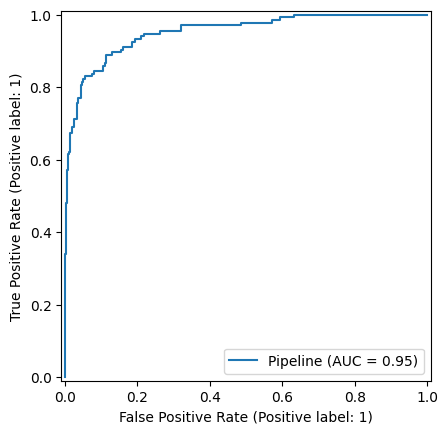

In [18]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.savefig('ROC Curve.png')
plt.show()

TreeExplainer works efficiently with tree-based models (RandomForest, XGBoost, LightGBM)

shap_values[1] corresponds to the positive class (Churn=1)

In [12]:

model = pipeline.named_steps['classifier']

X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed)


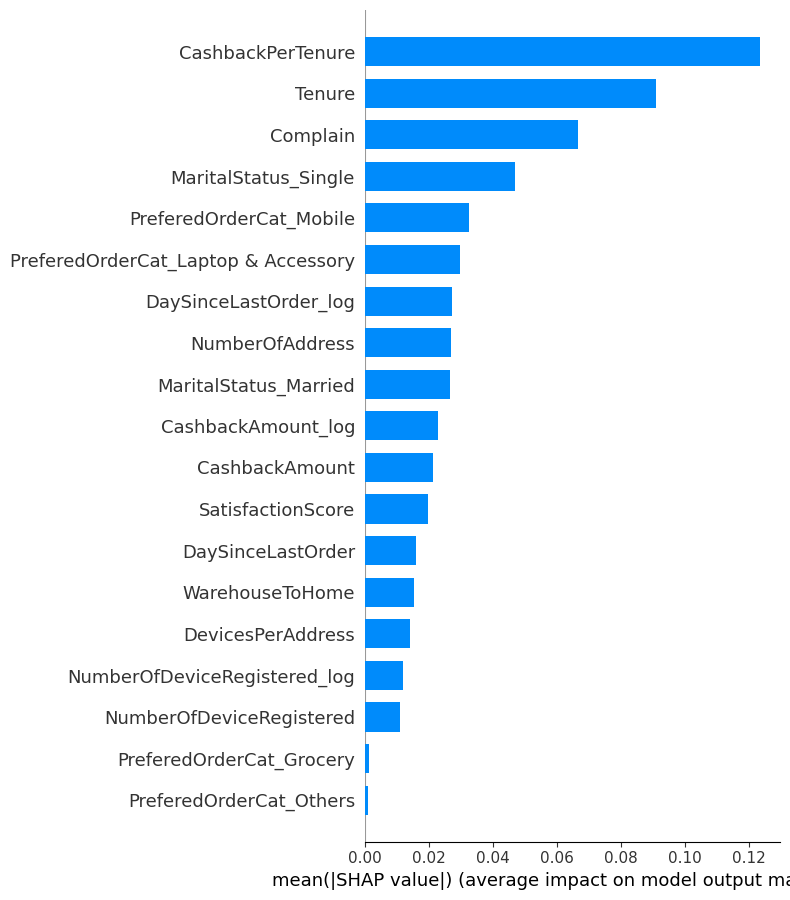

In [14]:
shap.summary_plot(shap_values[:, :, 1], X_train_transformed, feature_names=numeric_features + categorical_features, plot_type='bar')

Shows top features contributing to churn prediction globally

Features with highest absolute SHAP value → most influential

In [21]:
plt.figure(figsize=(10, 6))


shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=numeric_features + categorical_features,
    show=False
)

plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.close()

## Beeswarm plot visualizes how feature values impact prediction:

* Red → high feature value

* Blue → low feature value

* Direction of points → whether feature increases/decreases churn probability

# Training with other models

In [24]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}


In [25]:
results = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="roc_auc", n_jobs=-1)

    results[name] = np.mean(scores)
    print(f"{name}: {np.mean(scores):.4f}")


LogisticRegression: 0.8940
DecisionTree: 0.8444
RandomForest: 0.9580
GradientBoosting: 0.9301
SVM: 0.9059
XGBoost: 0.9597


In [26]:
best_model_name = max(results, key=results.get)
print("\nBest model:", best_model_name, "ROC-AUC:", results[best_model_name])



Best model: XGBoost ROC-AUC: 0.9597316779588286


#XGBoost

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [28]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

In [29]:
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb_base)
])

In [30]:
param_dist = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.2, 0.3],
    'model__min_child_weight': [1, 3, 5, 7]
}

In [31]:
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='auc',
                                                            feature_types=None,
                                                            feature_weights=None,
                                                            gamma=None,...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__gamma': [0, 0.1, 0.2, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [200, 300, 400,
                                                                500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [32]:
print("Best ROC-AUC:", random_search.best_score_)
print("Best Params:")
print(random_search.best_params_)

Best ROC-AUC: 0.956088033516074
Best Params:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__gamma': 0, 'model__colsample_bytree': 0.9}


In [33]:
best_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,

    # Best Params
    subsample=0.9,
    n_estimators=200,
    min_child_weight=1,
    max_depth=6,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.9
)


In [34]:


final_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', best_xgb)
])

final_pipe.fit(X_train, y_train)


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='auc',
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [35]:

y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


ROC-AUC: 0.9623060369237739

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       654
           1       0.86      0.83      0.85       135

    accuracy                           0.95       789
   macro avg       0.91      0.90      0.91       789
weighted avg       0.95      0.95      0.95       789


Confusion Matrix:
 [[636  18]
 [ 23 112]]


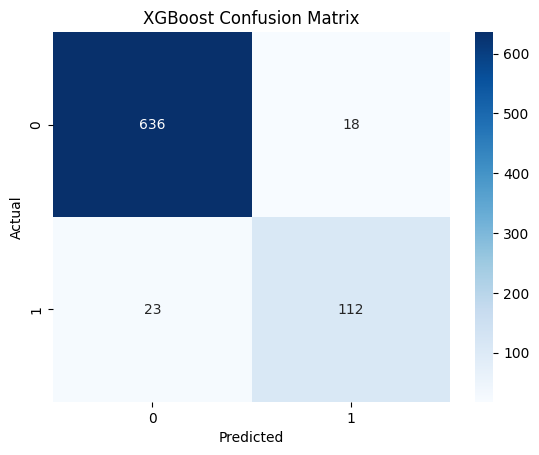

In [37]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.savefig('XGBoost confusion Matrix.png')
plt.show()

In [36]:
import joblib

joblib.dump(final_pipe, "churn_xgboost_model.pkl")
print("Model saved as churn_xgboost_model.pkl")


Model saved as churn_xgboost_model.pkl
